In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/drug200.csv")

In [3]:
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [5]:
df.head(50)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
5,22,F,NORMAL,HIGH,8.607,drugX
6,49,F,NORMAL,HIGH,16.275,drugY
7,41,M,LOW,HIGH,11.037,drugC
8,60,M,NORMAL,HIGH,15.171,drugY
9,43,M,LOW,NORMAL,19.368,drugY


In [6]:
df.tail(50)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
150,49,M,HIGH,NORMAL,8.700,drugA
151,68,M,HIGH,HIGH,11.009,drugB
152,55,M,NORMAL,NORMAL,7.261,drugX
153,72,F,LOW,NORMAL,14.642,drugX
154,37,M,LOW,NORMAL,16.724,drugY
155,49,M,LOW,HIGH,10.537,drugC
156,31,M,HIGH,NORMAL,11.227,drugA
157,53,M,LOW,HIGH,22.963,drugY
158,59,F,LOW,HIGH,10.444,drugC
159,34,F,LOW,NORMAL,12.923,drugX


In [7]:
df.isnull().sum()

,0
Age,0
Sex,0
BP,0
Cholesterol,0
Na_to_K,0
Drug,0


In [8]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


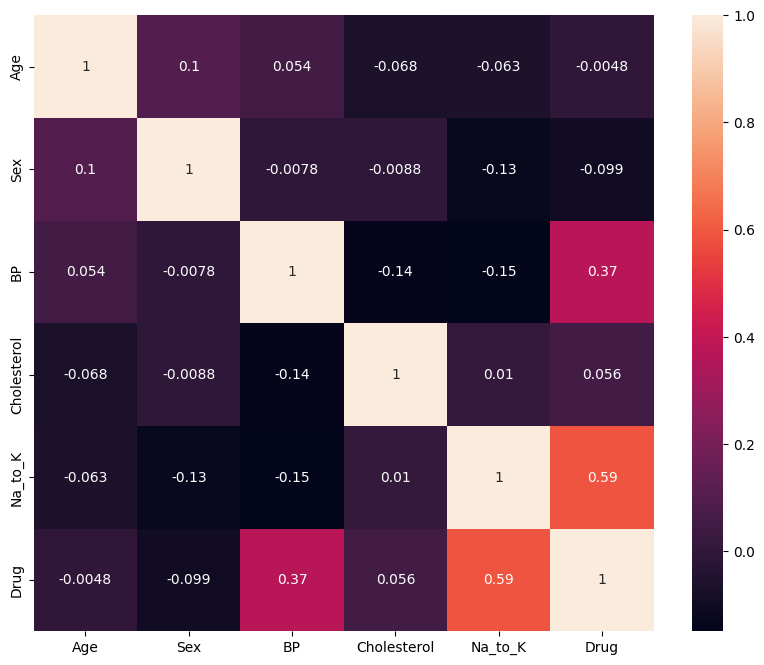

In [26]:
#correlation graph shown an relationship
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True)
plt.show()

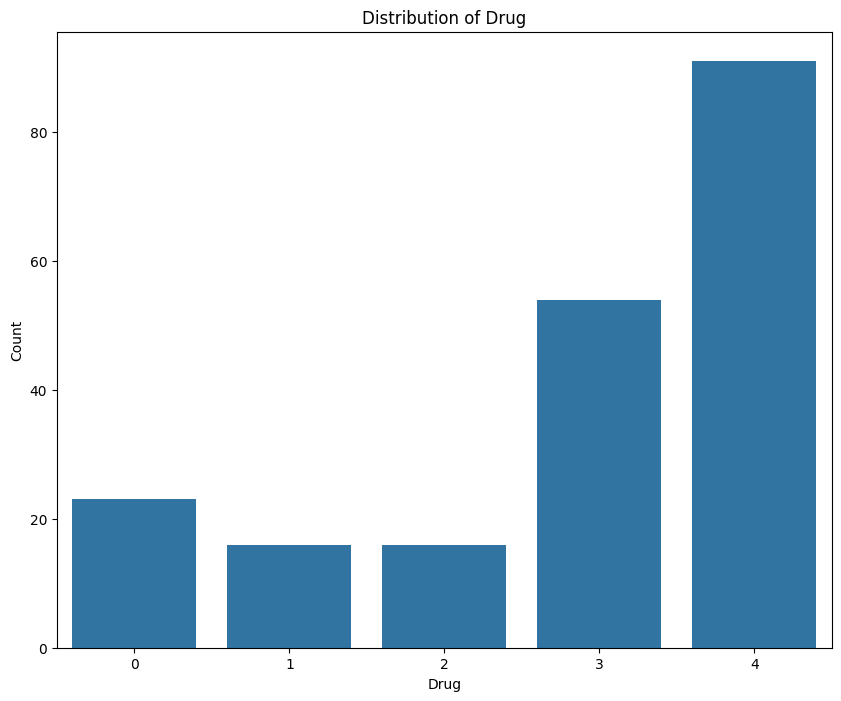

In [29]:
#Drug distribution
#Example distribution of patients across drug classes.

plt.figure(figsize=(10,8))
sns.countplot(x='Drug', data = df)
plt.xlabel('Drug')
plt.ylabel('Count')
plt.title('Distribution of Drug')
plt.show()

In [9]:
df[df.duplicated()]

,Age,Sex,BP,Cholesterol,Na_to_K,Drug


In [10]:
df['Drug'].value_counts()

,count
Drug,
drugY,91
drugX,54
drugA,23
drugC,16
drugB,16


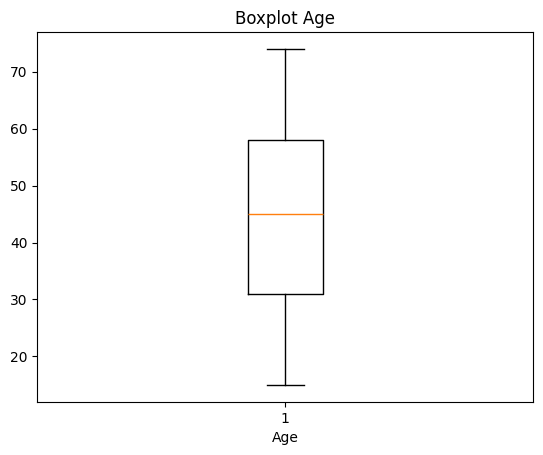

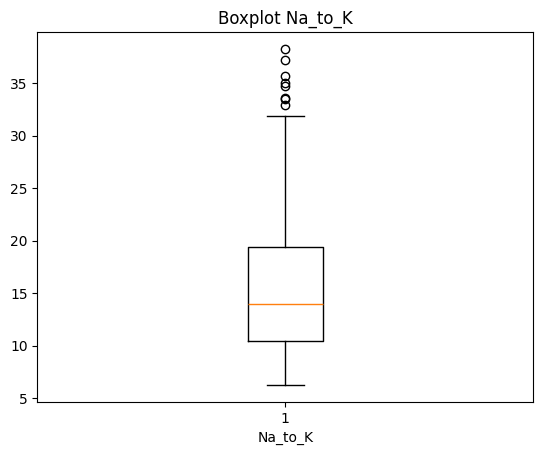

In [11]:
#finding outliers

for i in df.columns:
  if df[i].dtypes!='object':
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.title(f"Boxplot {i}")
    plt.show()


In [12]:
#Encoding

from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()

for i in df.columns:
  if df[i].dtypes == 'object':
    df[i] = LE.fit_transform(df[i])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int64  
 2   BP           200 non-null    int64  
 3   Cholesterol  200 non-null    int64  
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 9.5 KB


In [14]:
#Model building

x = df.drop('Drug',axis=1)
y = df['Drug']

In [15]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42 )



In [16]:

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()


dt = dt.fit(x_train,y_train)


dt_pred = dt.predict(x_test)

from sklearn.metrics import accuracy_score


print(accuracy_score(y_test,dt_pred)*100)

100.0


In [17]:
print(dt_pred)

[3 4 3 2 4 4 4 3 0 3 0 3 4 0 1 4 1 3 2 4 1 3 3 4 4 4 2 3 4 3 4 2 2 4 0 4 3
 0 4 0]


In [24]:
result = x_test.copy()
result['Actual_Drug'] = y_test
result['Predict_Drug'] = dt_pred

result['Actual_Drug'] = LE.inverse_transform(y_test)
result['Predict_Drug'] = LE.inverse_transform(dt_pred)

print(result)

     Age  Sex  BP  Cholesterol  Na_to_K Actual_Drug Predict_Drug
95    36    1   1            1   11.424       drugX        drugX
15    16    0   0            1   15.516       drugY        drugY
30    18    0   2            1    8.750       drugX        drugX
158   59    0   1            0   10.444       drugC        drugC
128   47    1   1            1   33.542       drugY        drugY
115   51    1   0            0   18.295       drugY        drugY
69    18    0   0            1   24.276       drugY        drugY
170   28    0   2            0   12.879       drugX        drugX
174   42    1   0            1   12.766       drugA        drugA
45    66    0   2            1    8.107       drugX        drugX
66    29    1   0            0   12.856       drugA        drugA
182   20    0   1            1   11.686       drugX        drugX
165   38    1   1            0   18.295       drugY        drugY
78    19    0   0            0   13.313       drugA        drugA
186   70    1   0        